# Origin of replication

**Goal:**
Show the timing of origin firing. Compare to the cluster of genes that represent origin of replication complexes.

**Plan**
1. Show the chromatin timing for known origin of replication.
2. Show the timing for a stack of efficient origins of replication

**Notes**
- Origins centered on annotated/known ARS locations
    (stack up will be in aggregate)
- Origins are a mix of efficient and inefficient origins


In [10]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
import glob

chromatin_dir = 'output/deconvolve_origins_g0066_11x11_2024_09_10/chromatin/'
f_filepaths = glob.glob(f'{chromatin_dir}/*f*')


In [43]:
from src.global_config import GlobalConstants
from src.origins import load_origins_w_replication

# The origins will be loaded out of order, so let's use the
# origin dataset to assign the loaded f numpy array in the proper order
origins = load_origins_w_replication(full=False)
origins['origin_index'] = np.arange(len(origins))

n = len(f_filepaths)

deconvolved_origin_fs = None
origin_identifiers = []
for i in range(n):
    filepath = f_filepaths[i]
    
    # Retrieve the origin identifiers
    filename_split = filepath.split('/')[-1].split('_')
    ori, ars_name = filename_split[-2], filename_split[-1].split('.')[0]
    oridb_name = 'oridb_' + ori

    origin_f = np.load(filepath)
    if i == 0:
        deconvolved_origin_fs = np.zeros((n, *origin_f.shape))
    origin_index = origins.loc[oridb_name].origin_index

    deconvolved_origin_fs[origin_index] = origin_f

shape = deconvolved_origin_fs.shape
deconvolved_origin_f_images = deconvolved_origin_fs.reshape((shape[0], shape[1], 
    *GlobalConstants.ORC_IMAGE_SHAPE))


In [ ]:
flipped_origins_f_images = deconvolved_origin_f_images.copy()
flipped_origins_f_images[upstream_loading_origins] = \
    np.flip(flipped_origins_f_images[upstream_loading_origins], axis=3)

In [75]:
late_efficient_origins_indices = origins[(origins.activation_time == 'late') & 
    (origins.derived_origin_efficiency_from_mcguffee_et_al_2013 > 0.5)].origin_index

early_efficient_origins_indices = origins[(origins.activation_time == 'early') & 
    (origins.derived_origin_efficiency_from_mcguffee_et_al_2013 > 0.5)].origin_index

In [72]:
upstream_loading_origins = origins[origins.mcm_loading_class == 'upstream'].origin_index

In [509]:
def plot_origins(origins_f, vmax=20):
    
    from src.figure_configs import FiguresConfig
    
    # Plot the origins at critical timepoints
    # Stack them up
    from src.config import load_configs_by_config_type
    config, _ = load_configs_by_config_type('shared')

    g1_indices = config.get_Hpositions_for_phase('CG1')
    s_indices = config.get_Hpositions_for_phase('S')
    g2m_indices = config.get_Hpositions_for_phase('G2M')

    from src.helpers import proportion_indices

    sel_g1_indices = proportion_indices(g1_indices, [0.2, 0.8])
    sel_s_indices = proportion_indices(s_indices, [0.2, 0.8])
    sel_g2m_indices = proportion_indices(g2m_indices, [0.2, 0.8])

    phase_indices = np.concatenate([
        sel_g1_indices,
        sel_s_indices,
        sel_g2m_indices
    ])

    combined_f_images = origins_f.mean(axis=0)

    def plot_origin_im(ax, f, plot_ticks=False):
        
        #if should_smooth_data:
        from src.helpers import smooth_data
        smoothed_f = smooth_data(f, size=5, sigma=0.5)

        ax.imshow(smoothed_f, aspect='auto', origin='lower', 
            cmap='magma_r', vmax=vmax, extent=GlobalConstants.ORC_BIN_EXTENTS)
        ax.set_yticks([])
        if plot_ticks: ax.set_xticks(np.arange(-600, 600, 200))
        else: ax.set_xticks([])
        ax.set_xlim(-500, 500)
        ax.axvline(0, c='gray', alpha=0.125)
    
    fig, axs = plt.subplots(2, 3, figsize=(11, 3))
    axs = np.array(axs).T.flatten()

    for i in range(len(axs)):
        ax = axs[i]
        f_index = phase_indices[i]

        if i == 1: plot_ticks = True
        else: plot_ticks = False
            
        plot_origin_im(ax, combined_f_images[f_index], plot_ticks)
        ax.set_ylabel(f"{i+1}", rotation=0, ha='right', 
                      fontsize=FiguresConfig.FIG_LABEL_FONTSIZE,
                     labelpad=7)
        
        if i == 0: ax.set_title("Shared G1", fontsize=FiguresConfig.FIG_TITLE_FONTSIZE)
        elif i == 2: ax.set_title("S",  fontsize=FiguresConfig.FIG_TITLE_FONTSIZE)
        elif i == 4: ax.set_title("G2M",  fontsize=FiguresConfig.FIG_TITLE_FONTSIZE)


In [488]:
from src.figure_configs import FiguresConfig

def plot_origin(origin):
    origin_index = origin.origin_index
    plot_origins(deconvolved_origin_f_images[origin_index:origin_index+1], vmax=20)
    plt.suptitle(f"{origin.ars_name}", 
        fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
    plt.subplots_adjust(top=0.80)

In [479]:
from src.peak_to_trough import compute_quantile_ptr_2d

# Find origins with the greatest cycling small fragments PTR
origin_small_fragments_occ = deconvolved_origin_f_images[:, t_indices, 0:10, :].mean(axis=2)
origin_small_fragments_occ_sum = origin_small_fragments_occ.sum(axis=2)

origin_small_ptrs = compute_quantile_ptr_2d(origin_small_fragments_occ_sum)
origin_ptrs = origins.copy()
origin_ptrs['small_ptr'] = origin_small_ptrs
sorted_origins_small_ptrs = origin_ptrs.sort_values('small_ptr', 
    ascending=False)[['ars_name', 'activation_time', 'derived_origin_efficiency_from_mcguffee_et_al_2013', 'small_ptr']]
sorted_origins_small_ptrs.head(5)

,ars_name,activation_time,derived_origin_efficiency_from_mcguffee_et_al_2013,small_ptr
name,,,,
oridb_625,ARS1330,early,0.6719,2.876861
oridb_418,ARS1004,late,0.1337,2.668594
oridb_498,ARS1120,late,0.7361,2.536307
oridb_628,ARS1331.7,late,0.0799,2.441841
oridb_551,NaN,late,-0.0091,2.325043


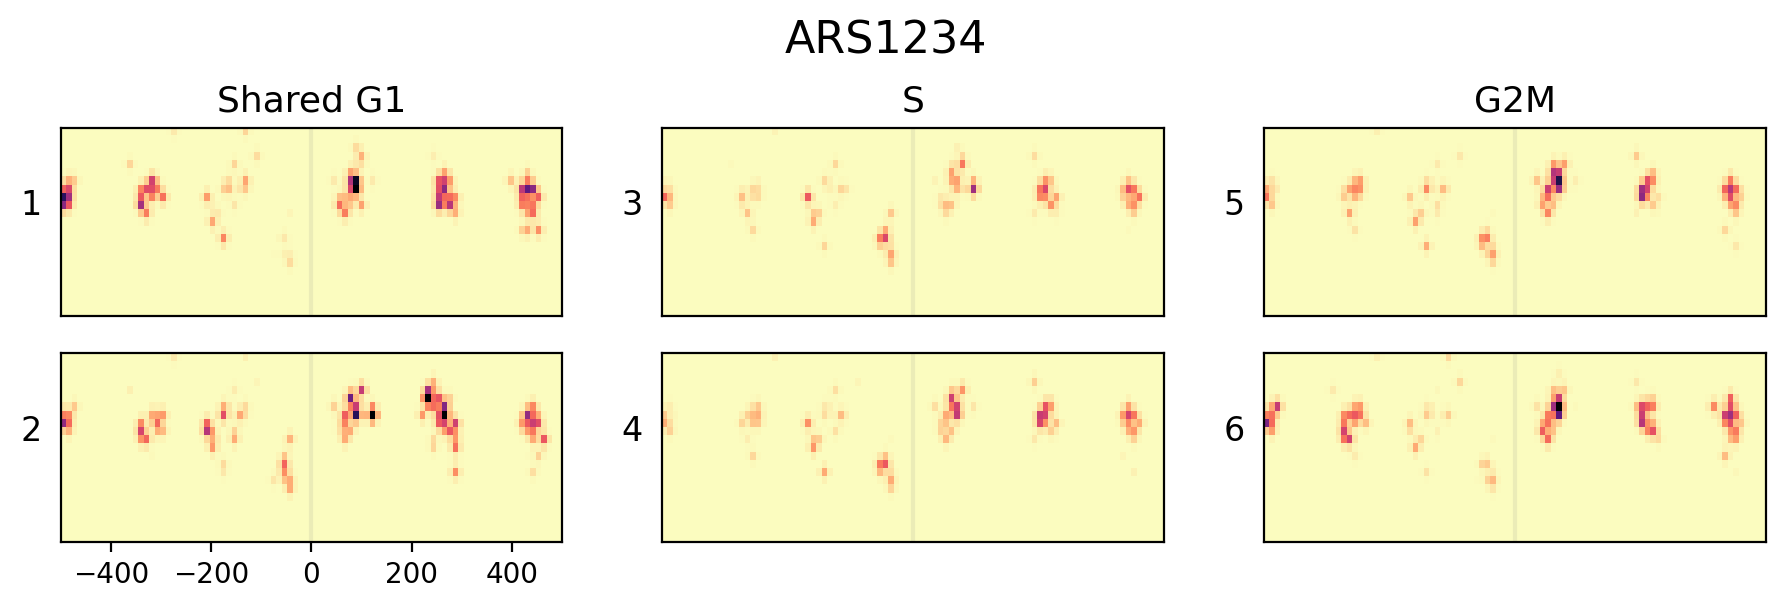

In [510]:
origin = origins.loc['oridb_567']
plot_origin(origin)

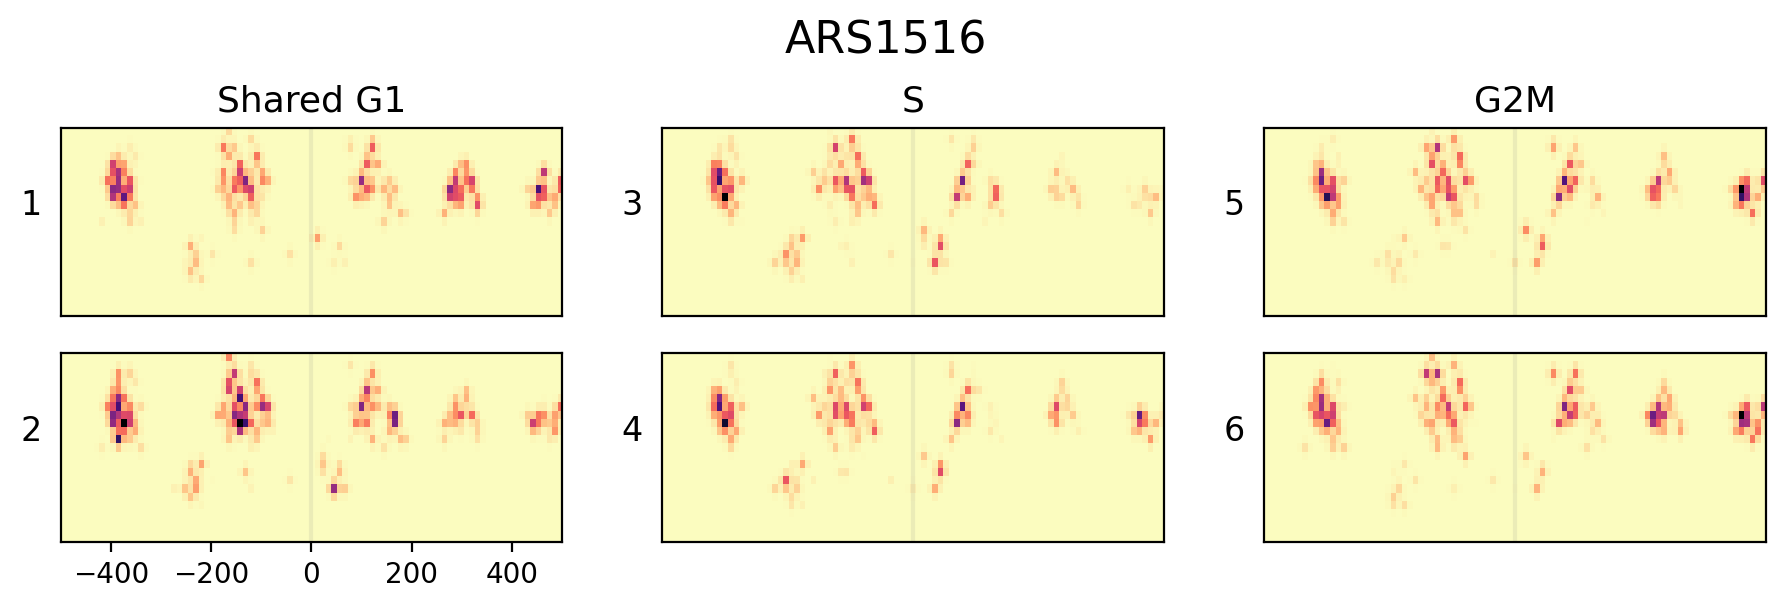

In [511]:
origin = origins.loc['oridb_721']
plot_origin(origin)

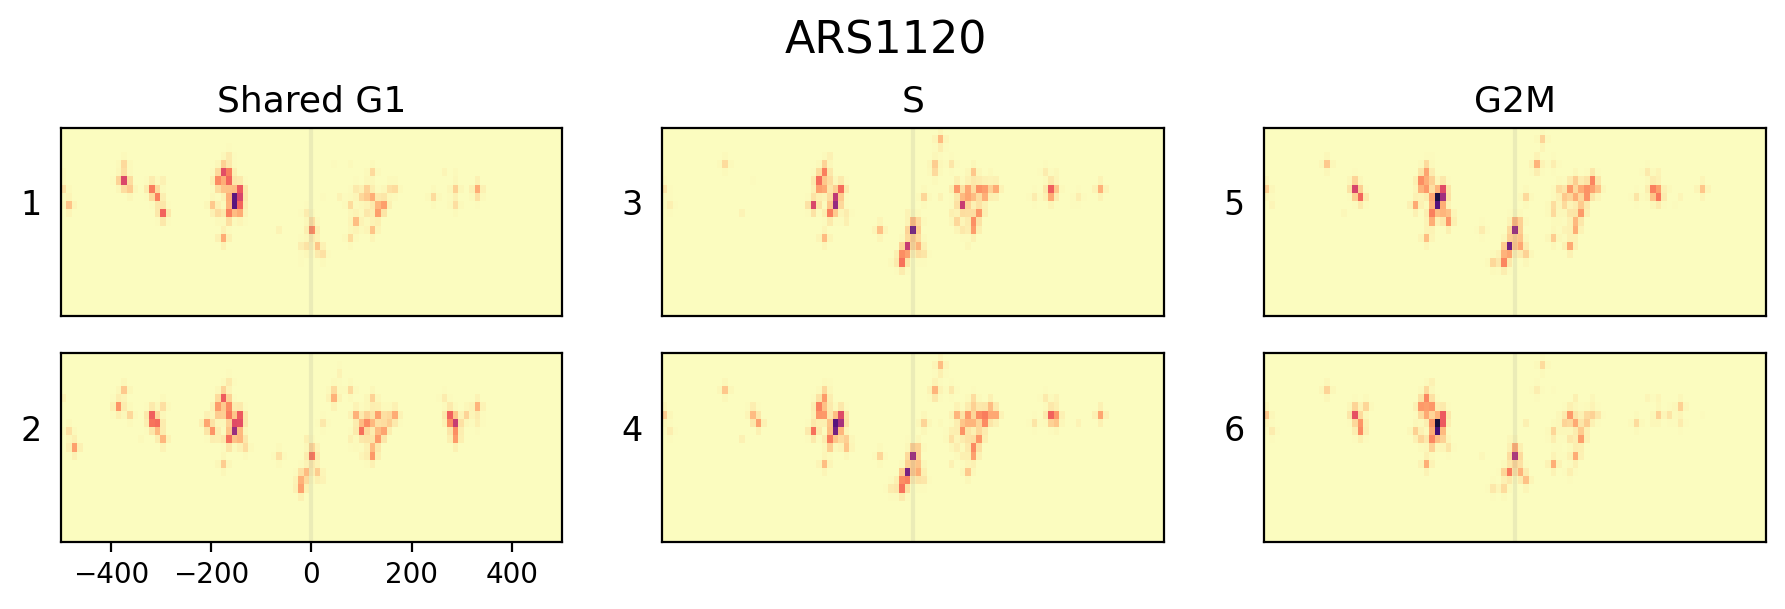

In [512]:
origin = origins.loc['oridb_498']
plot_origin(origin)